# DSA 210 – Milestone 1
## Analyzing Music Preferences and Audio Features Using Spotify Data
**Ayşe Gülcan Yörük** | Spring 2026

This notebook covers:
1. Data loading & cleaning
2. Exploratory Data Analysis (EDA)
3. Hypothesis Tests

## 0. Imports & Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})

IMAGES = 'images/'
DATA_FILE = 'gulcan_spotify_formatted.json'

print('Setup complete.')

Setup complete.


## 1. Data Loading & Cleaning

In [2]:
with open(DATA_FILE, encoding='utf-8') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df['endTime'] = pd.to_datetime(df['endTime'], format='%Y-%m-%d %H:%M')

# Feature columns
AUDIO_FEATURES = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

print(f'Total records: {len(df)}')
print(f'Date range: {df["endTime"].min().date()} → {df["endTime"].max().date()}')
print(f'Unique tracks: {df["trackName"].nunique()}')
print(f'Unique artists: {df["artistName"].nunique()}')
df.head(3)

Total records: 1558
Date range: 2025-04-11 → 2026-04-10
Unique tracks: 1535
Unique artists: 921


,artistName,trackName,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,endTime
0,Barış Diri,Derinden / bazen hayat çok kötü gidiyor ve ben...,0.668,0.218,11,-13.131,0,0.0478,0.8180,0.001200,0.109,0.0396,129.744,2025-04-11 08:04:00
1,Isabel LaRosa,HEARTBEAT,0.542,0.729,2,-7.453,1,0.0881,0.0977,0.000009,0.488,0.3370,120.879,2025-04-11 18:27:00
2,Elley Duhé,MIDDLE OF THE NIGHT,0.410,0.611,4,-8.271,0,0.0467,0.0228,0.000000,0.116,0.0899,185.727,2025-04-11 18:29:00


In [3]:
# Basic stats
df[AUDIO_FEATURES].describe().round(3)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1558.000,1558.000,1558.000,1558.000,1558.000,1558.000,1558.000,1558.000,1558.000
mean,0.481,0.559,-9.365,0.066,0.374,0.217,0.175,0.347,121.270
std,0.173,0.280,5.703,0.057,0.367,0.355,0.128,0.227,32.921
min,0.068,0.002,-42.041,0.023,0.000,0.000,0.035,0.000,49.452
25%,0.360,0.324,-12.213,0.035,0.023,0.000,0.098,0.158,94.045
50%,0.491,0.592,-7.969,0.045,0.230,0.000,0.121,0.310,119.990
75%,0.601,0.798,-5.218,0.070,0.736,0.368,0.221,0.504,144.470
max,0.950,0.997,-0.413,0.474,0.996,0.985,0.979,0.975,209.873


In [4]:
# Missing values check
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None')

Missing values per column:
None


## 2. Exploratory Data Analysis

### 2.1 Audio Feature Distributions

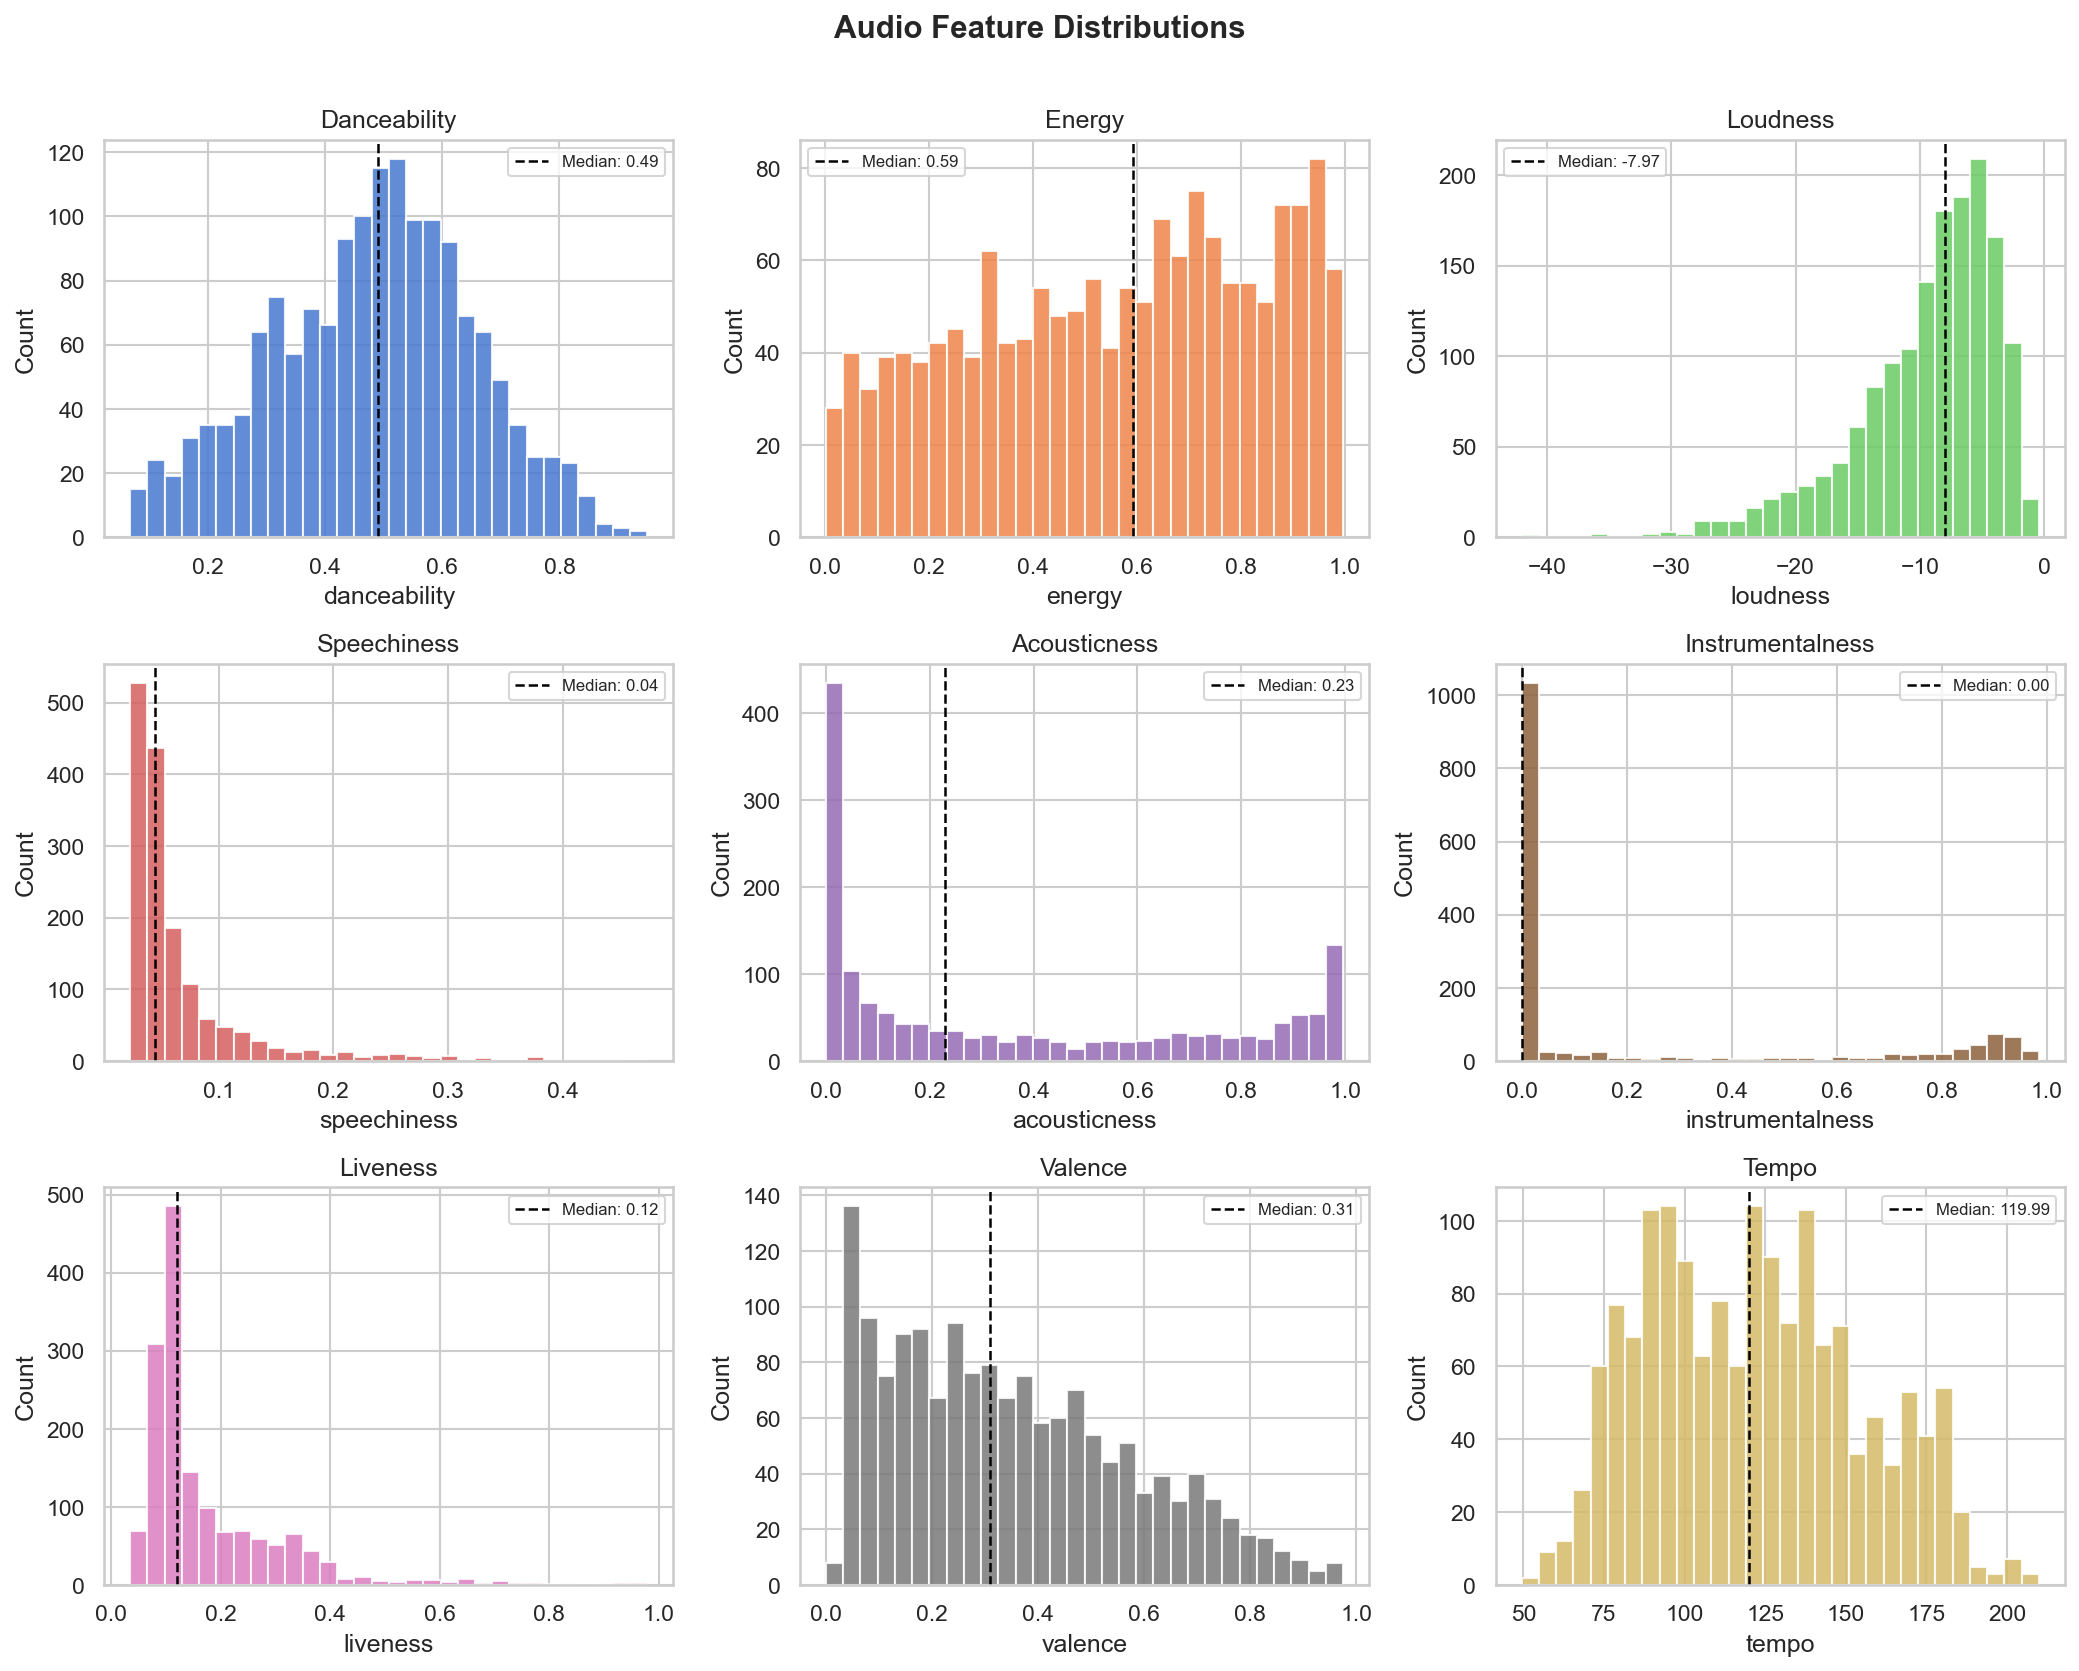

Saved: fig1_feature_distributions.png


In [5]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()

colors = sns.color_palette('muted', 9)

for i, feat in enumerate(AUDIO_FEATURES):
    axes[i].hist(df[feat].dropna(), bins=30, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(df[feat].median(), color='black', linestyle='--', linewidth=1.2, label=f'Median: {df[feat].median():.2f}')
    axes[i].set_title(feat.capitalize())
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Audio Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES + 'fig1_feature_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: fig1_feature_distributions.png')

### 2.2 Correlation Heatmap

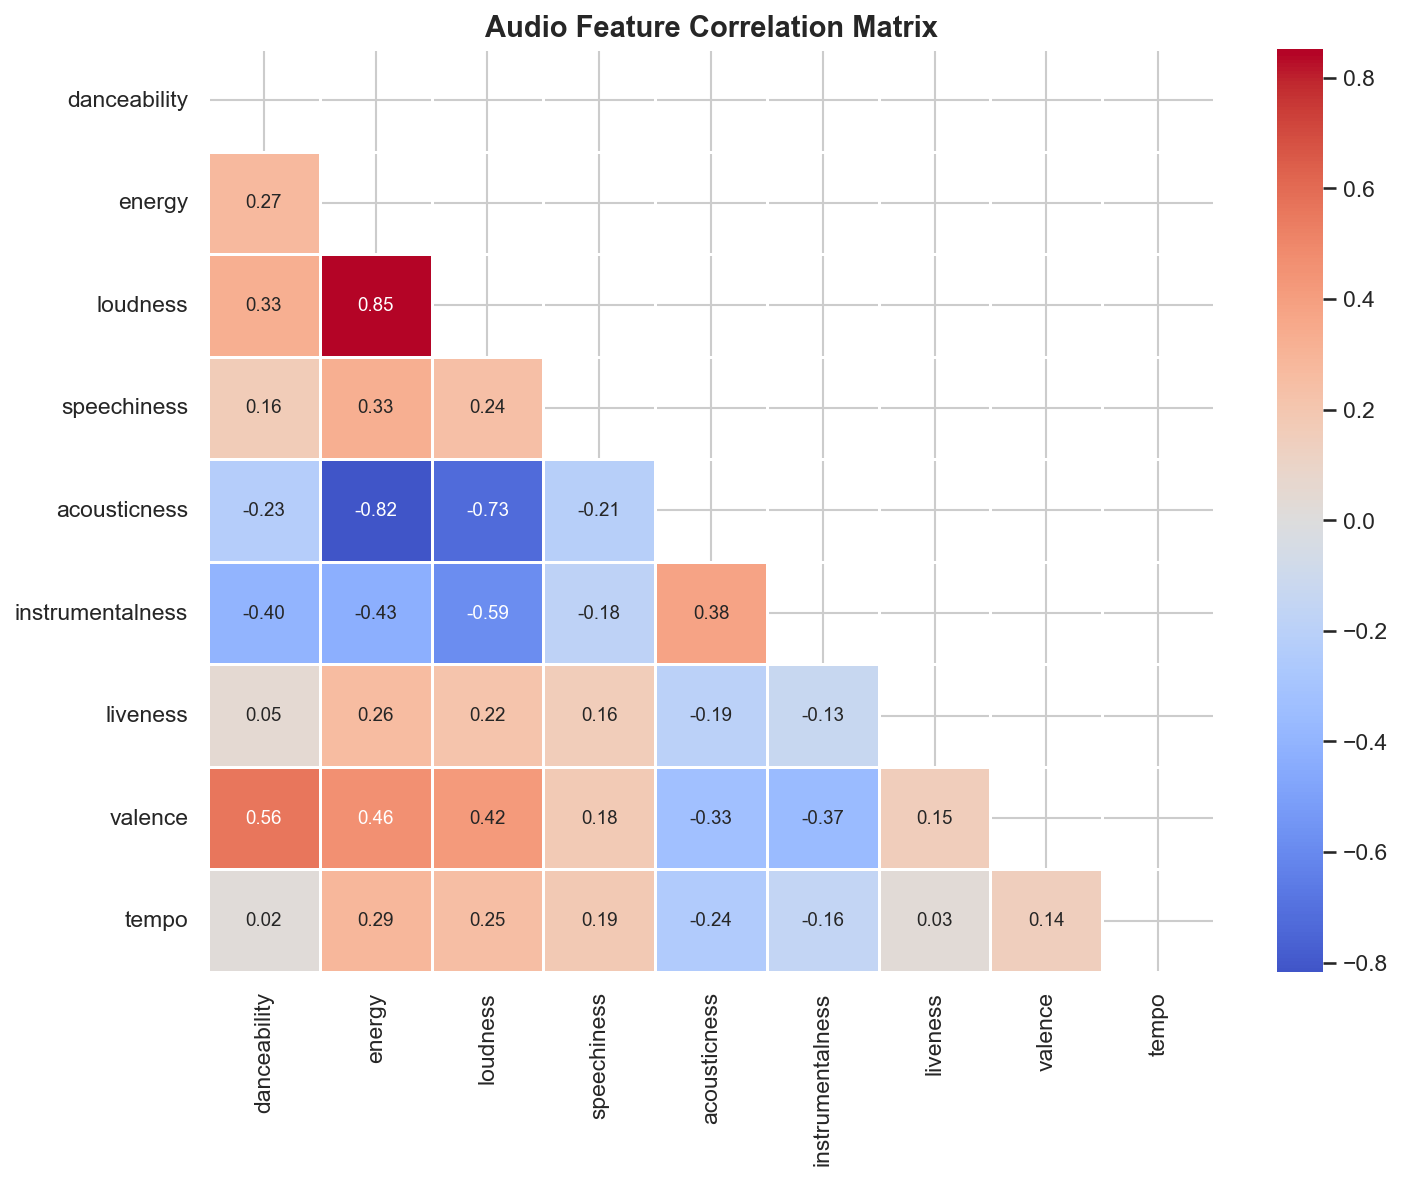

Saved: fig2_correlation_heatmap.png


In [6]:
corr = df[AUDIO_FEATURES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Audio Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES + 'fig2_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: fig2_correlation_heatmap.png')

### 2.3 Top Artists & Tracks

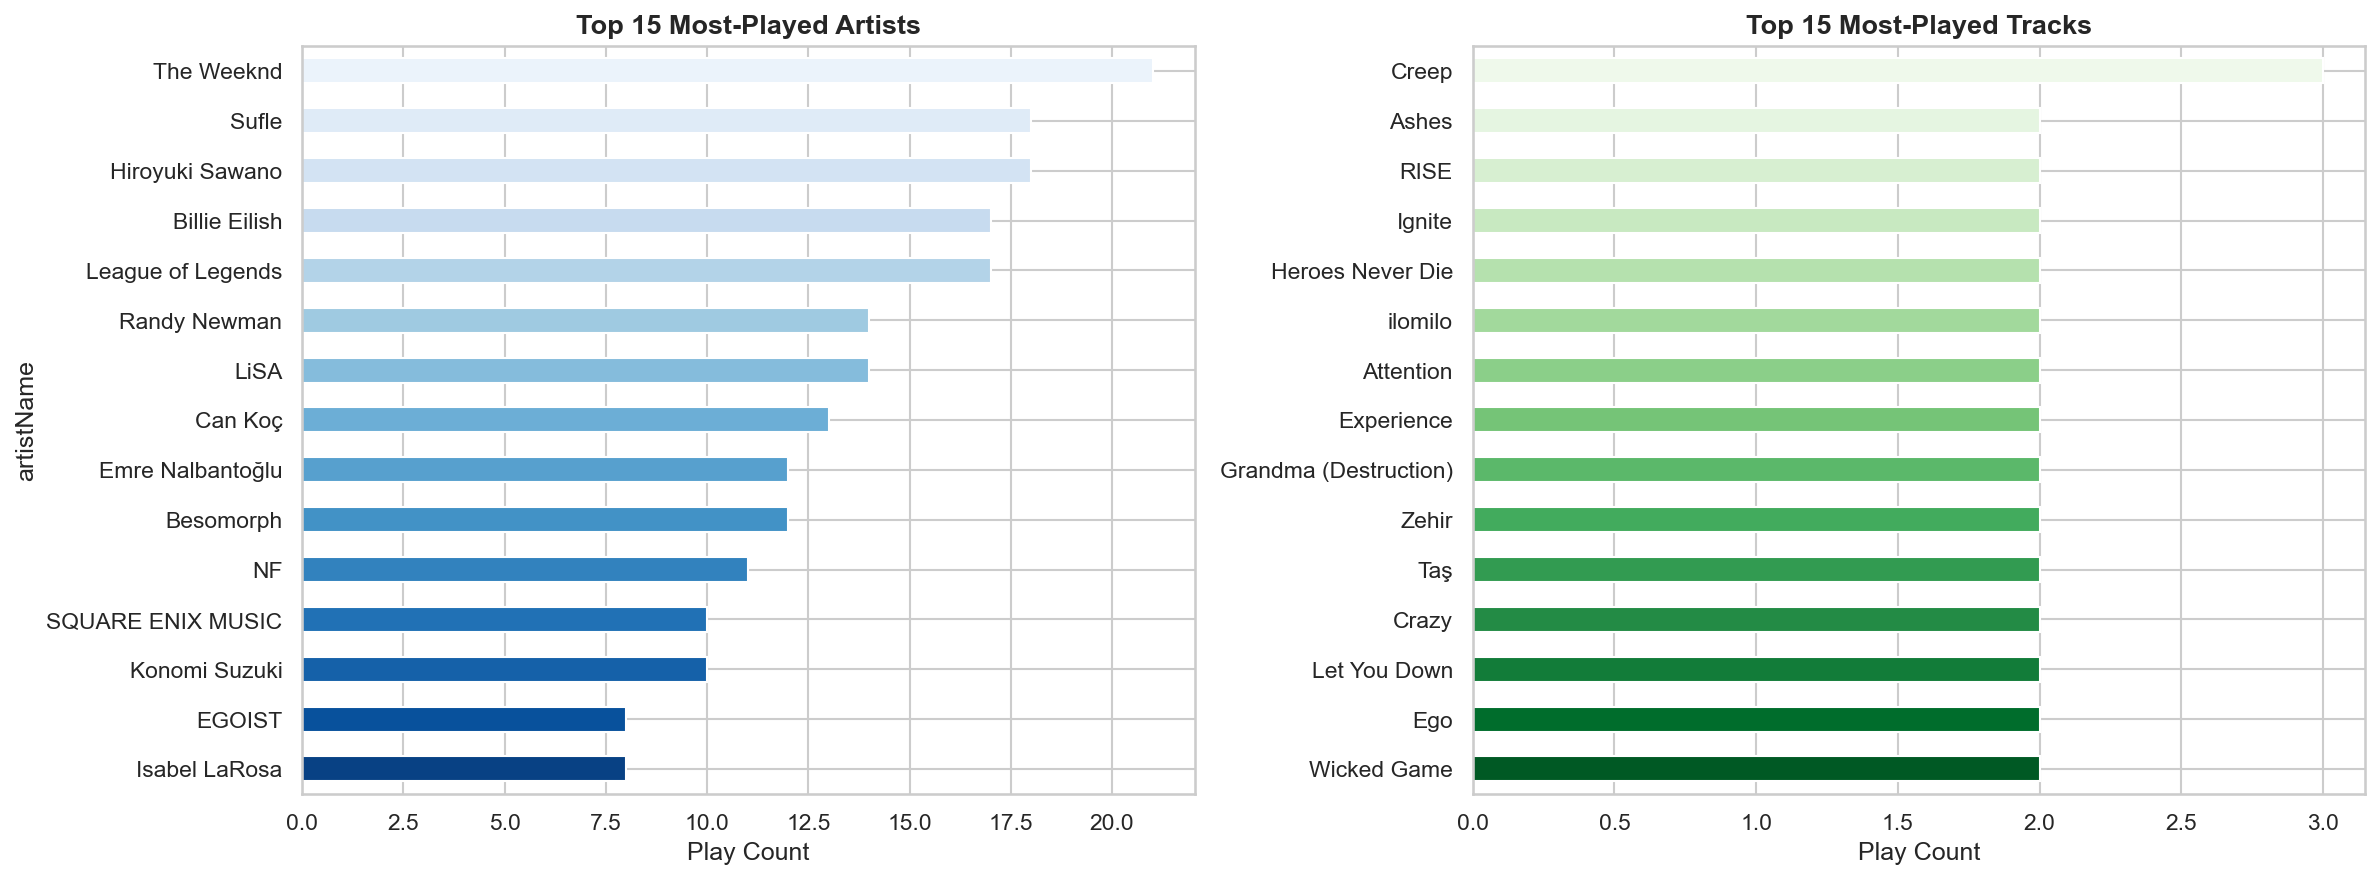

Saved: fig3_top_artists_tracks.png


In [7]:
top_artists = df['artistName'].value_counts().head(15)
top_tracks  = df['trackName'].value_counts().head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors_a = sns.color_palette('Blues_r', 15)
top_artists.sort_values().plot(kind='barh', ax=ax1, color=colors_a)
ax1.set_title('Top 15 Most-Played Artists', fontsize=13, fontweight='bold')
ax1.set_xlabel('Play Count')

colors_t = sns.color_palette('Greens_r', 15)
# Truncate long track names
top_tracks_short = top_tracks.copy()
top_tracks_short.index = [t[:35] + '...' if len(t) > 35 else t for t in top_tracks_short.index]
top_tracks_short.sort_values().plot(kind='barh', ax=ax2, color=colors_t)
ax2.set_title('Top 15 Most-Played Tracks', fontsize=13, fontweight='bold')
ax2.set_xlabel('Play Count')

plt.tight_layout()
plt.savefig(IMAGES + 'fig3_top_artists_tracks.png', bbox_inches='tight')
plt.show()
print('Saved: fig3_top_artists_tracks.png')

### 2.4 Listening Activity Over Time

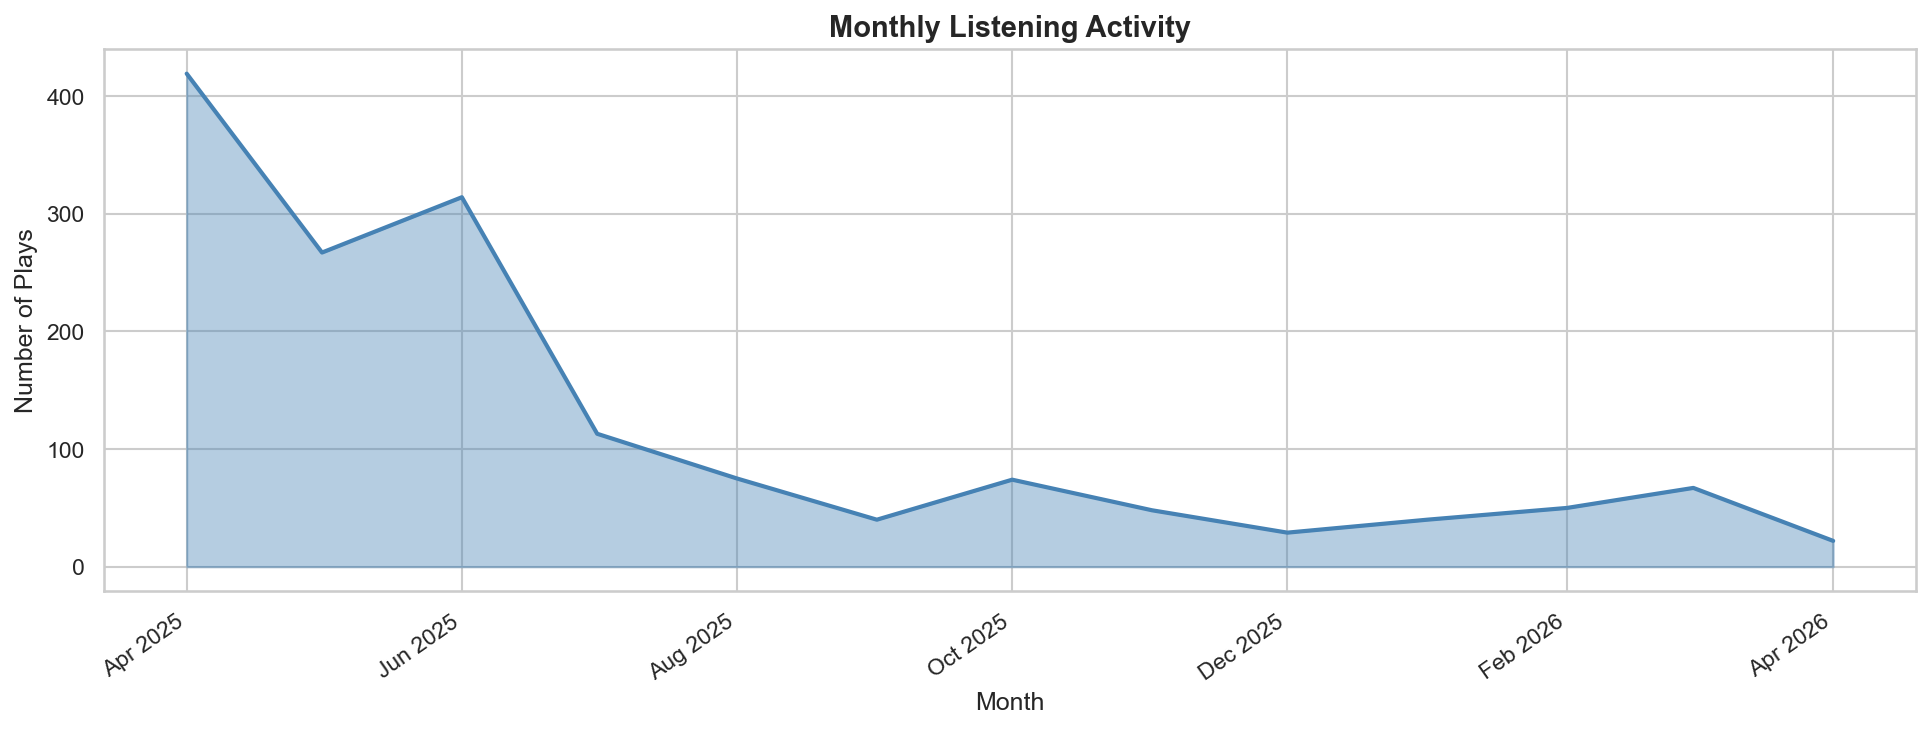

Saved: fig4_monthly_activity.png


In [8]:
df['month'] = df['endTime'].dt.to_period('M')
monthly_counts = df.groupby('month').size().reset_index(name='plays')
monthly_counts['month_dt'] = monthly_counts['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(monthly_counts['month_dt'], monthly_counts['plays'],
                alpha=0.4, color='steelblue')
ax.plot(monthly_counts['month_dt'], monthly_counts['plays'],
        color='steelblue', linewidth=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=35, ha='right')
ax.set_title('Monthly Listening Activity', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Plays')
plt.tight_layout()
plt.savefig(IMAGES + 'fig4_monthly_activity.png', bbox_inches='tight')
plt.show()
print('Saved: fig4_monthly_activity.png')

### 2.5 Listening by Hour of Day

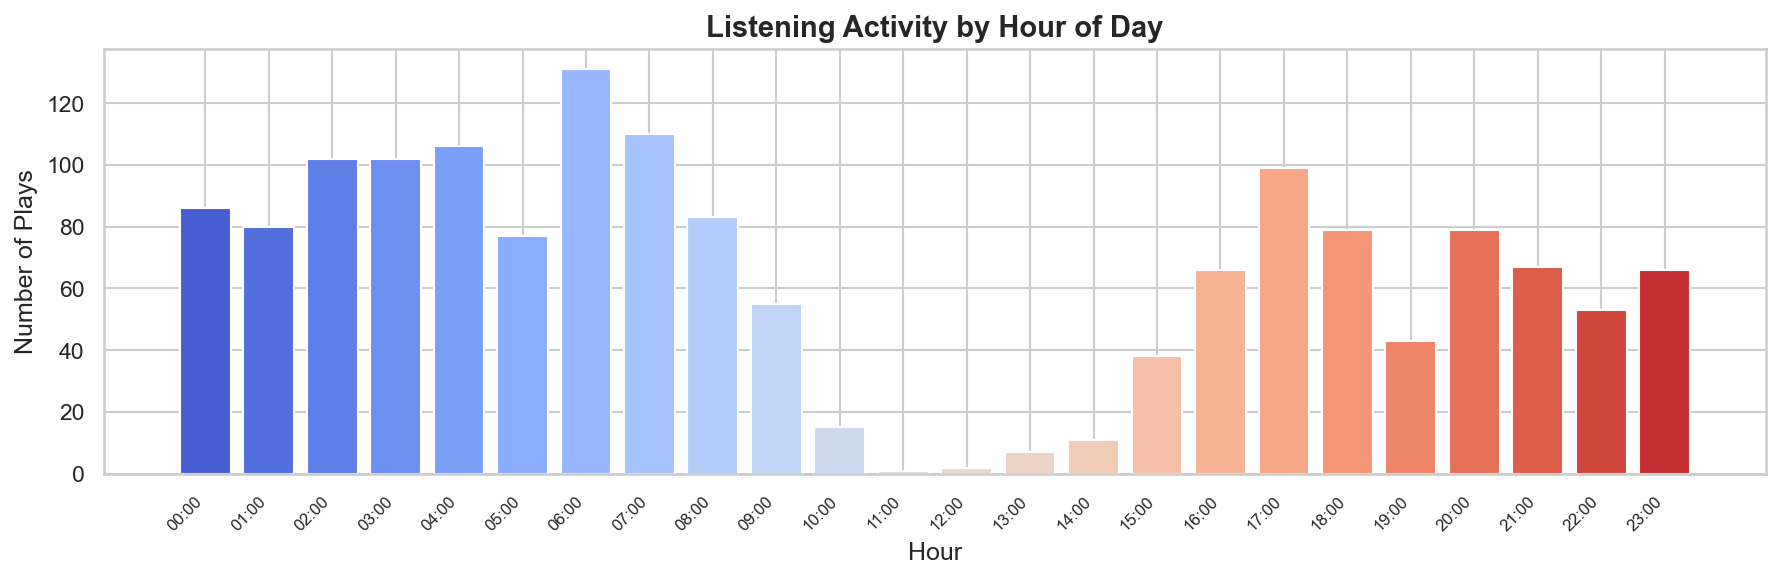

Saved: fig5_hourly_activity.png


In [9]:
df['hour'] = df['endTime'].dt.hour
hour_counts = df.groupby('hour').size()

fig, ax = plt.subplots(figsize=(12, 4))
palette = sns.color_palette('coolwarm', 24)
bars = ax.bar(hour_counts.index, hour_counts.values, color=palette, edgecolor='white')
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right', fontsize=8)
ax.set_title('Listening Activity by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Number of Plays')
plt.tight_layout()
plt.savefig(IMAGES + 'fig5_hourly_activity.png', bbox_inches='tight')
plt.show()
print('Saved: fig5_hourly_activity.png')

### 2.6 Valence Over Time (Mood Trend)

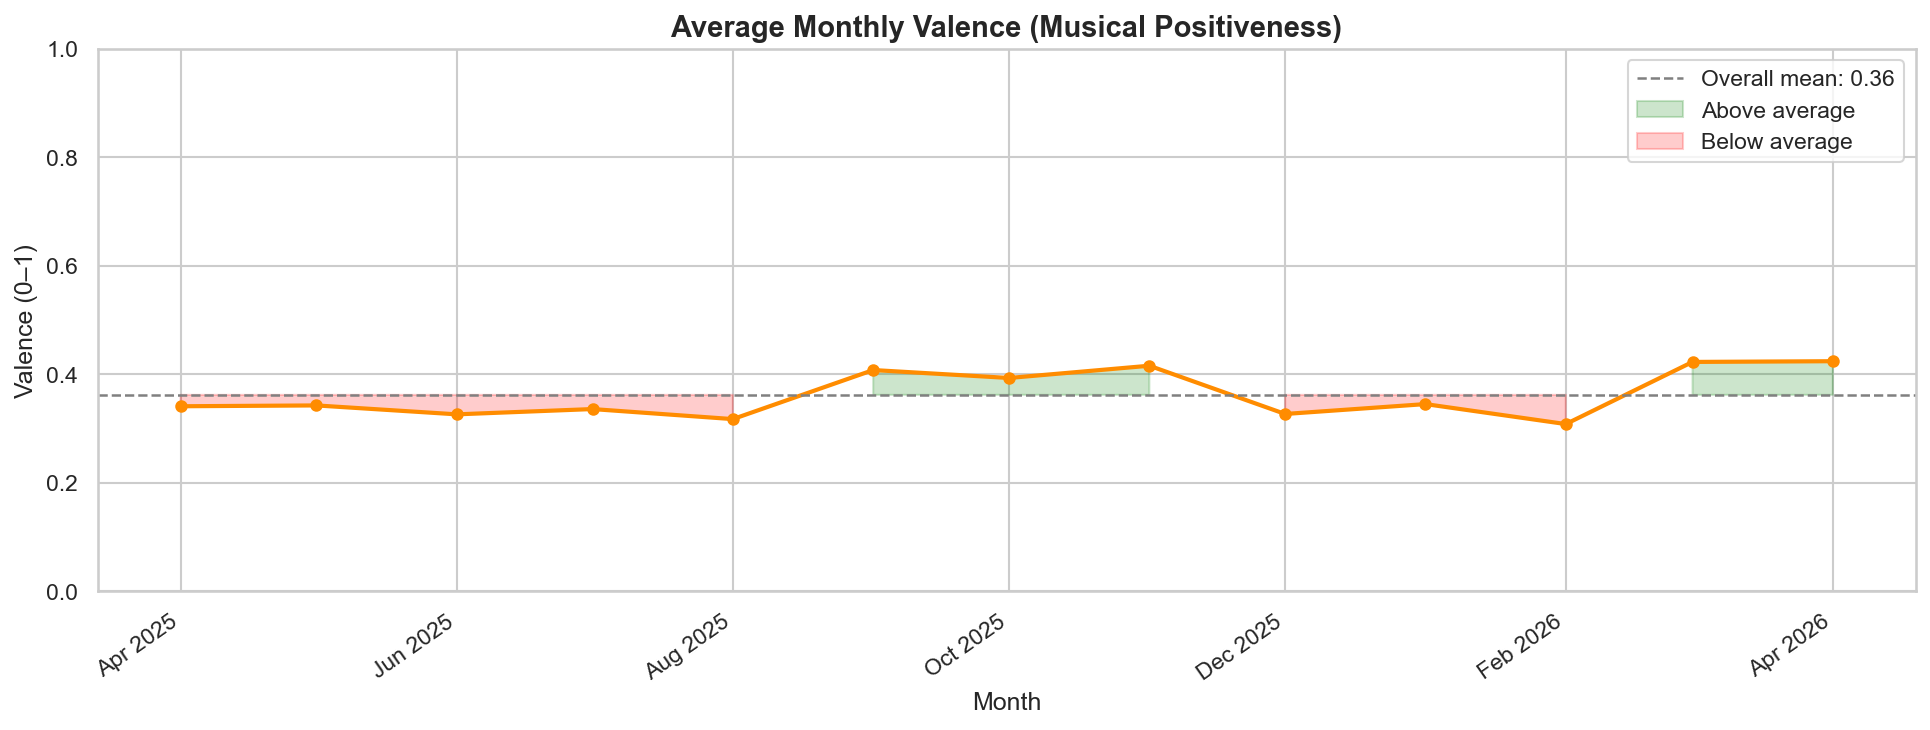

Saved: fig6_valence_over_time.png


In [10]:
monthly_valence = df.groupby('month')['valence'].mean().reset_index()
monthly_valence['month_dt'] = monthly_valence['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_valence['month_dt'], monthly_valence['valence'],
        color='darkorange', linewidth=2, marker='o', markersize=5)
ax.axhline(monthly_valence['valence'].mean(), color='gray', linestyle='--',
           linewidth=1.2, label=f'Overall mean: {monthly_valence["valence"].mean():.2f}')
ax.fill_between(monthly_valence['month_dt'], monthly_valence['valence'],
                monthly_valence['valence'].mean(),
                where=monthly_valence['valence'] >= monthly_valence['valence'].mean(),
                alpha=0.2, color='green', label='Above average')
ax.fill_between(monthly_valence['month_dt'], monthly_valence['valence'],
                monthly_valence['valence'].mean(),
                where=monthly_valence['valence'] < monthly_valence['valence'].mean(),
                alpha=0.2, color='red', label='Below average')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=35, ha='right')
ax.set_ylim(0, 1)
ax.set_title('Average Monthly Valence (Musical Positiveness)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Valence (0–1)')
ax.legend()
plt.tight_layout()
plt.savefig(IMAGES + 'fig6_valence_over_time.png', bbox_inches='tight')
plt.show()
print('Saved: fig6_valence_over_time.png')

### 2.7 Energy vs Valence Scatter

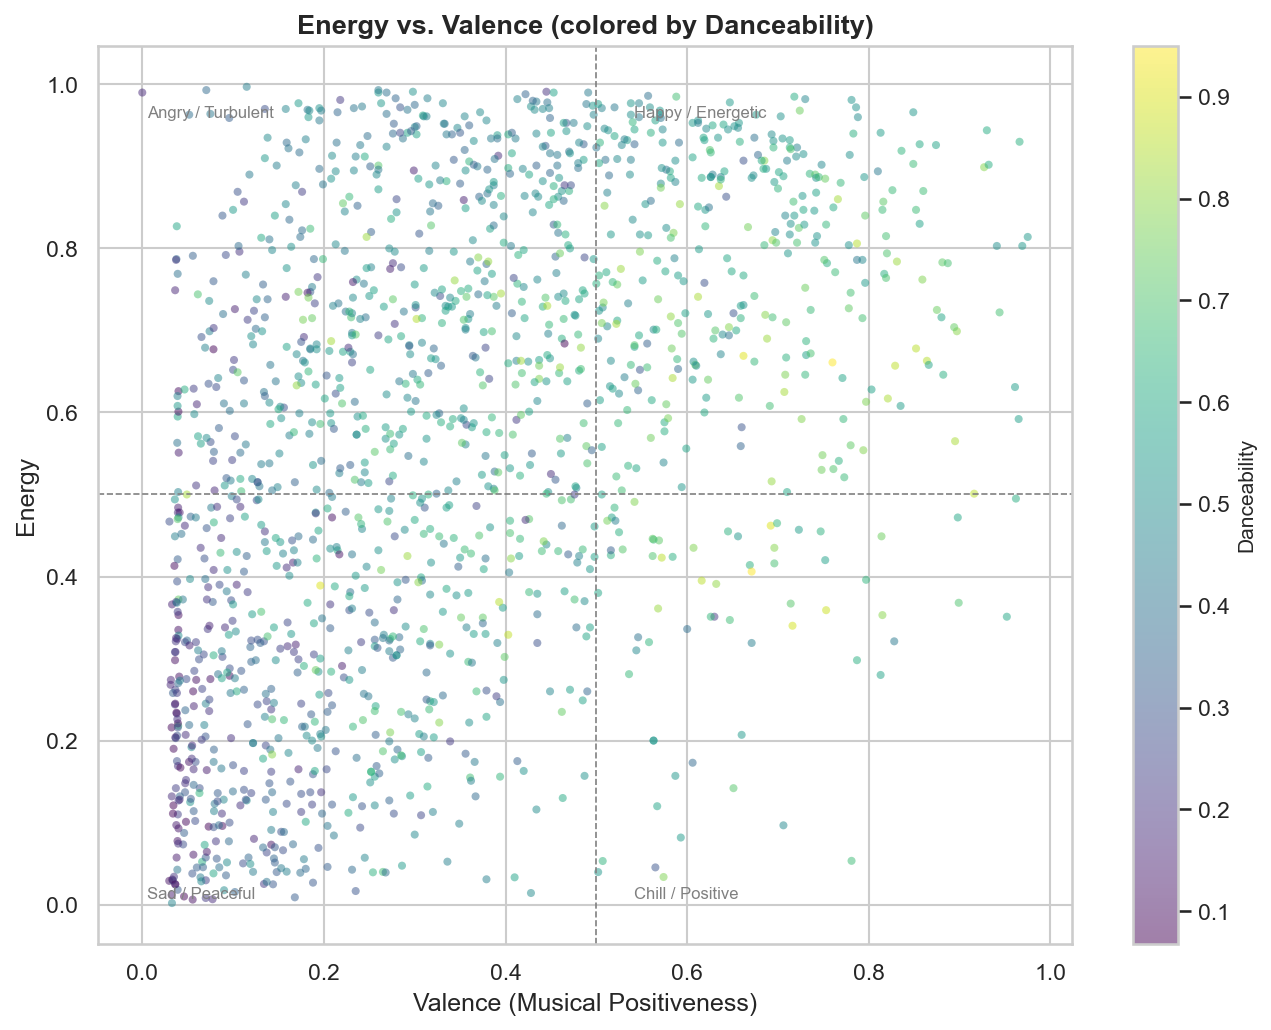

Saved: fig7_energy_valence_scatter.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(df['valence'], df['energy'],
                     c=df['danceability'], cmap='viridis',
                     alpha=0.5, s=15, edgecolors='none')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Danceability', fontsize=10)

# Quadrant lines
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

# Quadrant labels
ax.text(0.05, 0.92, 'Angry / Turbulent', transform=ax.transAxes, fontsize=8, color='gray')
ax.text(0.55, 0.92, 'Happy / Energetic',  transform=ax.transAxes, fontsize=8, color='gray')
ax.text(0.05, 0.05, 'Sad / Peaceful',     transform=ax.transAxes, fontsize=8, color='gray')
ax.text(0.55, 0.05, 'Chill / Positive',   transform=ax.transAxes, fontsize=8, color='gray')

ax.set_xlabel('Valence (Musical Positiveness)')
ax.set_ylabel('Energy')
ax.set_title('Energy vs. Valence (colored by Danceability)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES + 'fig7_energy_valence_scatter.png', bbox_inches='tight')
plt.show()
print('Saved: fig7_energy_valence_scatter.png')

### 2.8 Listening by Day of Week

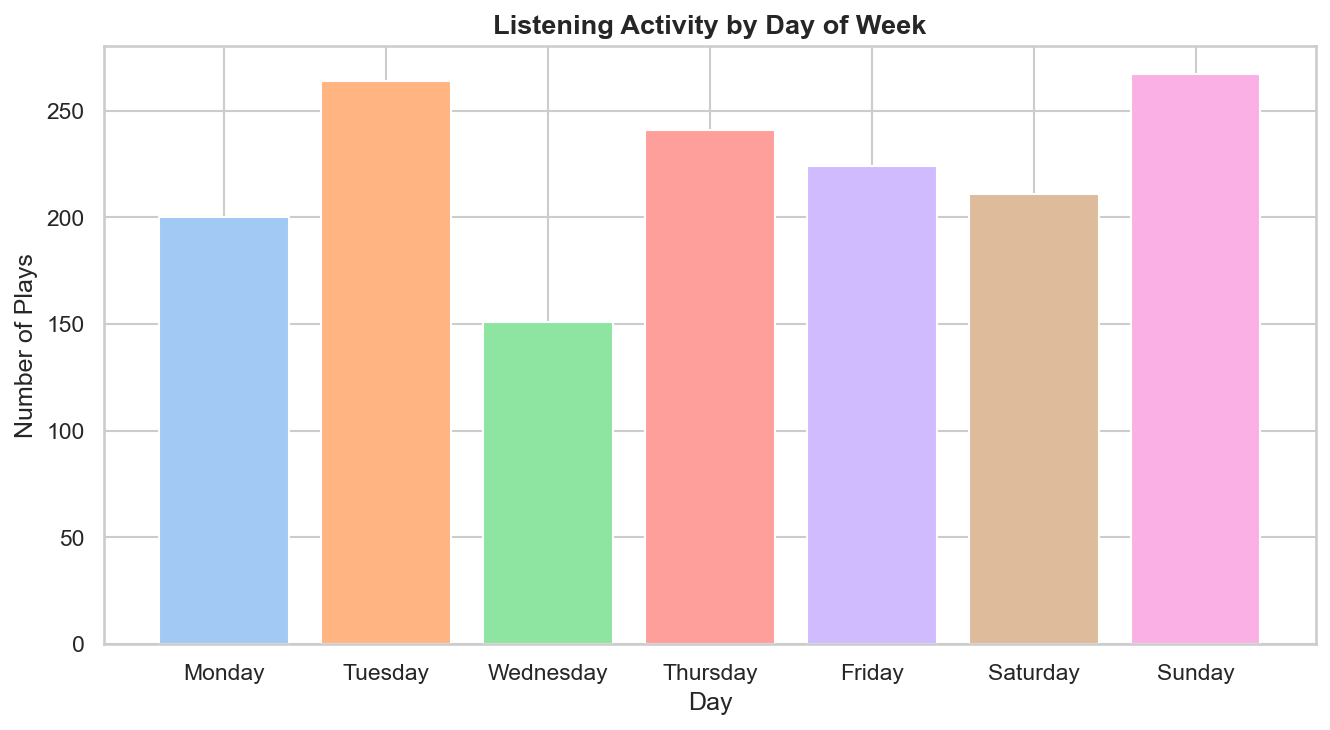

Saved: fig8_dayofweek_activity.png


In [12]:
df['dayofweek'] = df['endTime'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['dayofweek'].value_counts().reindex(day_order)

fig, ax = plt.subplots(figsize=(9, 5))
palette_day = sns.color_palette('pastel', 7)
ax.bar(day_counts.index, day_counts.values, color=palette_day, edgecolor='white')
ax.set_title('Listening Activity by Day of Week', fontsize=13, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Number of Plays')
plt.tight_layout()
plt.savefig(IMAGES + 'fig8_dayofweek_activity.png', bbox_inches='tight')
plt.show()
print('Saved: fig8_dayofweek_activity.png')

## 3. Hypothesis Tests

Significance level: **α = 0.05**

### H1: High-energy songs are played more frequently than low-energy songs

- H₀: Mean play frequency of high-energy tracks = low-energy tracks
- H₁: High-energy tracks are played more (one-tailed)

**Approach:** Count how many times each track appears (play count as proxy), split by energy threshold.

In [13]:
track_counts = df.groupby('trackName').agg(
    play_count=('trackName', 'count'),
    energy=('energy', 'mean')
).reset_index()

high_energy = track_counts[track_counts['energy'] >= 0.7]['play_count']
low_energy  = track_counts[track_counts['energy'] <  0.5]['play_count']

print(f'High-energy tracks (≥0.7): n={len(high_energy)}, mean plays={high_energy.mean():.2f}')
print(f'Low-energy  tracks (<0.5): n={len(low_energy)},  mean plays={low_energy.mean():.2f}')

# Normality check
_, p_norm_h = stats.shapiro(high_energy[:50] if len(high_energy) > 50 else high_energy)
_, p_norm_l = stats.shapiro(low_energy[:50]  if len(low_energy)  > 50 else low_energy)
print(f'\nShapiro-Wilk p-value (high-energy): {p_norm_h:.4f}')
print(f'Shapiro-Wilk p-value (low-energy):  {p_norm_l:.4f}')

# Use Mann-Whitney (non-parametric) as normality likely violated
stat, p_val = stats.mannwhitneyu(high_energy, low_energy, alternative='greater')
print(f'\nMann-Whitney U test (one-tailed):')
print(f'  U = {stat:.1f},  p = {p_val:.4f}')
if p_val < 0.05:
    print('  → REJECT H₀: High-energy songs are played significantly more.')
else:
    print('  → FAIL TO REJECT H₀: No significant difference.')

High-energy tracks (≥0.7): n=571, mean plays=1.01
Low-energy  tracks (<0.5): n=625,  mean plays=1.01

Shapiro-Wilk p-value (high-energy): 1.0000
Shapiro-Wilk p-value (low-energy):  1.0000

Mann-Whitney U test (one-tailed):
  U = 177375.0,  p = 0.8707
  → FAIL TO REJECT H₀: No significant difference.


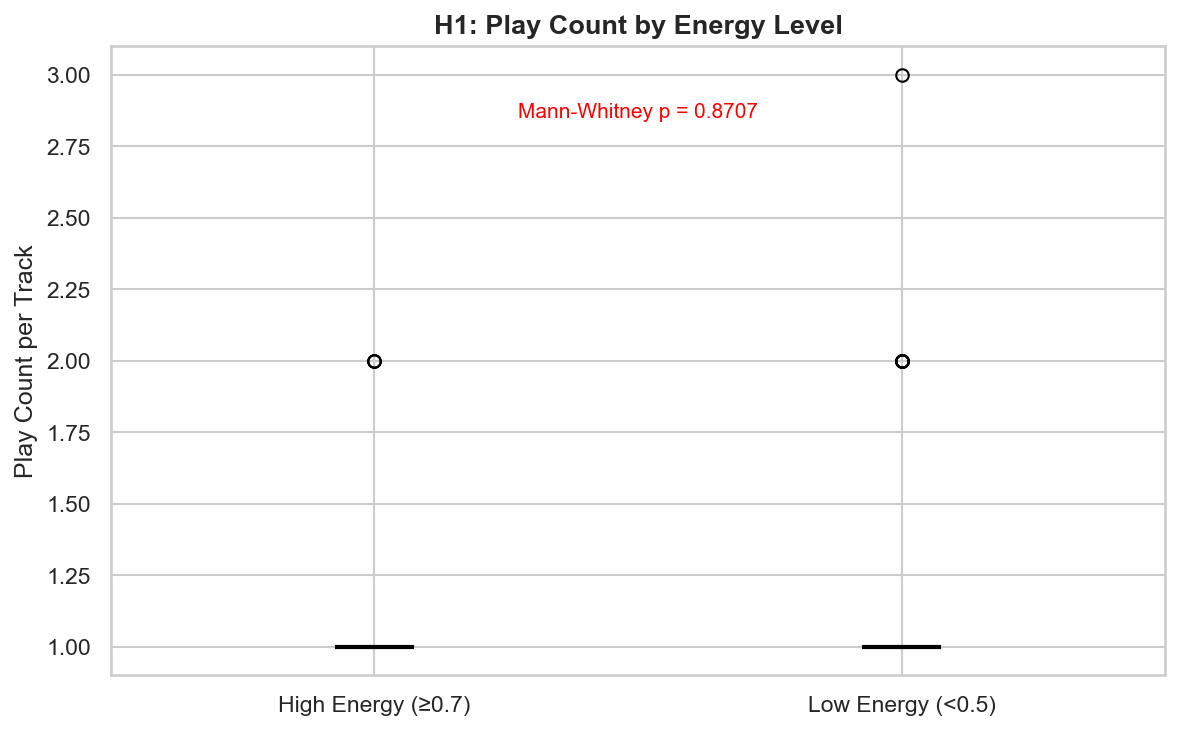

Saved: fig9_h1_energy_playcount.png


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([high_energy, low_energy], labels=['High Energy (≥0.7)', 'Low Energy (<0.5)'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='black', linewidth=2))
ax.set_ylabel('Play Count per Track')
ax.set_title('H1: Play Count by Energy Level', fontsize=13, fontweight='bold')
ax.annotate(f'Mann-Whitney p = {p_val:.4f}',
            xy=(1.5, max(high_energy.max(), low_energy.max()) * 0.95),
            ha='center', fontsize=10,
            color='green' if p_val < 0.05 else 'red')
plt.tight_layout()
plt.savefig(IMAGES + 'fig9_h1_energy_playcount.png', bbox_inches='tight')
plt.show()
print('Saved: fig9_h1_energy_playcount.png')

### H2: Valence is higher in summer months than winter months

- H₀: Mean valence (summer) = mean valence (winter)
- H₁: Mean valence (summer) ≠ mean valence (winter) (two-tailed)

In [15]:
df['month_num'] = df['endTime'].dt.month
summer = df[df['month_num'].isin([6, 7, 8])]['valence']
winter = df[df['month_num'].isin([12, 1, 2])]['valence']

print(f'Summer valence: n={len(summer)}, mean={summer.mean():.3f}, std={summer.std():.3f}')
print(f'Winter valence: n={len(winter)}, mean={winter.mean():.3f}, std={winter.std():.3f}')

stat2, p_val2 = stats.mannwhitneyu(summer, winter, alternative='two-sided')
print(f'\nMann-Whitney U test (two-tailed):')
print(f'  U = {stat2:.1f},  p = {p_val2:.4f}')
if p_val2 < 0.05:
    print('  → REJECT H₀: Valence differs significantly between summer and winter.')
else:
    print('  → FAIL TO REJECT H₀: No significant seasonal difference in valence.')

Summer valence: n=502, mean=0.327, std=0.219
Winter valence: n=119, mean=0.325, std=0.226

Mann-Whitney U test (two-tailed):
  U = 30258.5,  p = 0.8250
  → FAIL TO REJECT H₀: No significant seasonal difference in valence.


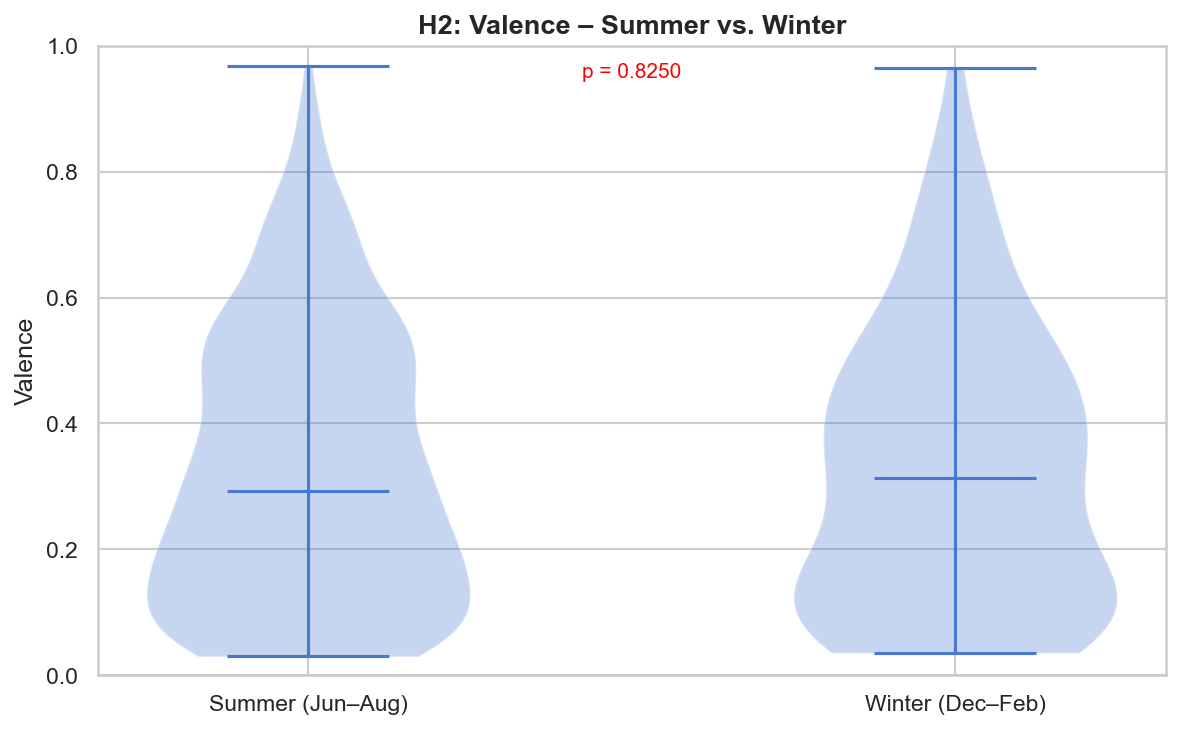

Saved: fig10_h2_valence_seasons.png


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.violinplot([summer.dropna(), winter.dropna()], positions=[1, 2],
              showmedians=True)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Summer (Jun–Aug)', 'Winter (Dec–Feb)'])
ax.set_ylabel('Valence')
ax.set_title('H2: Valence – Summer vs. Winter', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1)
ax.annotate(f'p = {p_val2:.4f}',
            xy=(1.5, 0.95), ha='center', fontsize=10,
            color='green' if p_val2 < 0.05 else 'red')
plt.tight_layout()
plt.savefig(IMAGES + 'fig10_h2_valence_seasons.png', bbox_inches='tight')
plt.show()
print('Saved: fig10_h2_valence_seasons.png')

### H3: Acoustic songs have lower tempo than non-acoustic songs

- H₀: Mean tempo of acoustic tracks (acousticness ≥ 0.7) = non-acoustic tracks (acousticness < 0.3)
- H₁: Acoustic tracks have lower tempo (one-tailed)

In [17]:
acoustic     = df[df['acousticness'] >= 0.7]['tempo']
non_acoustic = df[df['acousticness'] <  0.3]['tempo']

print(f'Acoustic tracks (≥0.7):     n={len(acoustic)}, mean tempo={acoustic.mean():.1f} BPM')
print(f'Non-acoustic tracks (<0.3): n={len(non_acoustic)}, mean tempo={non_acoustic.mean():.1f} BPM')

stat3, p_val3 = stats.mannwhitneyu(acoustic, non_acoustic, alternative='less')
print(f'\nMann-Whitney U test (one-tailed, acoustic < non-acoustic):')
print(f'  U = {stat3:.1f},  p = {p_val3:.4f}')
if p_val3 < 0.05:
    print('  → REJECT H₀: Acoustic songs have significantly lower tempo.')
else:
    print('  → FAIL TO REJECT H₀: No significant tempo difference.')

Acoustic tracks (≥0.7):     n=422, mean tempo=109.6 BPM
Non-acoustic tracks (<0.3): n=842, mean tempo=127.8 BPM

Mann-Whitney U test (one-tailed, acoustic < non-acoustic):
  U = 120140.0,  p = 0.0000
  → REJECT H₀: Acoustic songs have significantly lower tempo.


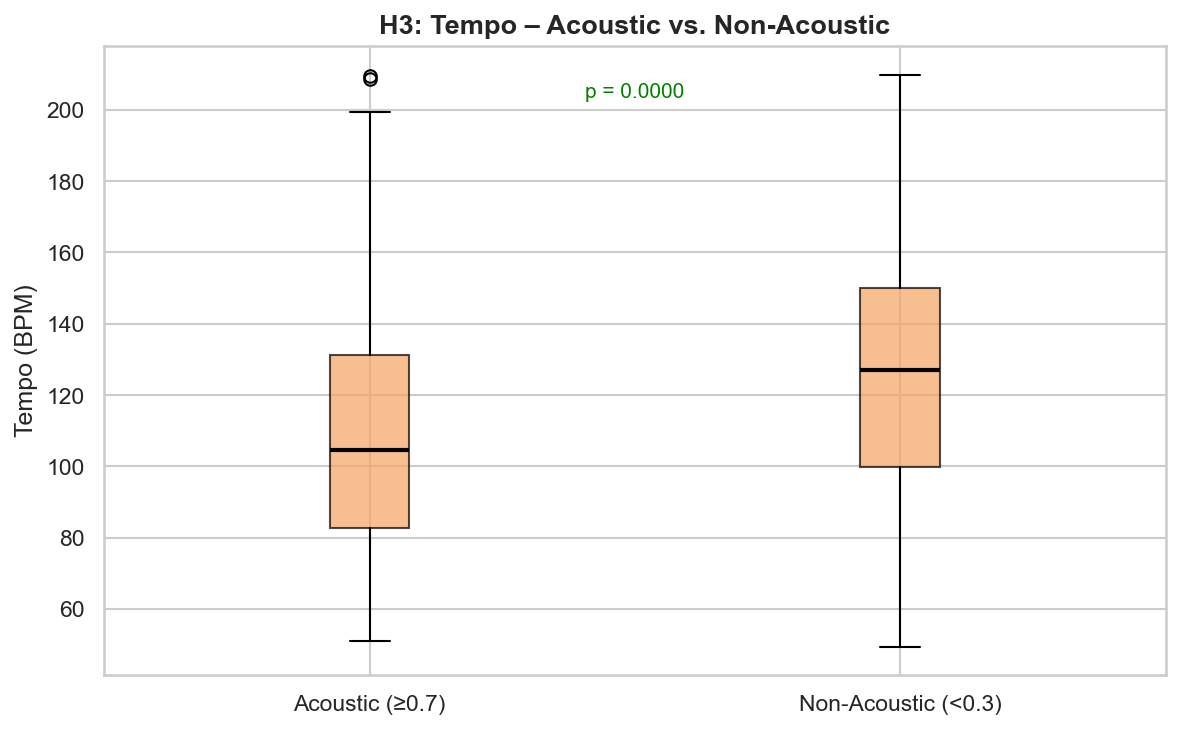

Saved: fig11_h3_acoustic_tempo.png


In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([acoustic.dropna(), non_acoustic.dropna()],
           labels=['Acoustic (≥0.7)', 'Non-Acoustic (<0.3)'],
           patch_artist=True,
           boxprops=dict(facecolor='sandybrown', alpha=0.7),
           medianprops=dict(color='black', linewidth=2))
ax.set_ylabel('Tempo (BPM)')
ax.set_title('H3: Tempo – Acoustic vs. Non-Acoustic', fontsize=13, fontweight='bold')
ax.annotate(f'p = {p_val3:.4f}',
            xy=(1.5, max(acoustic.max(), non_acoustic.max()) * 0.97),
            ha='center', fontsize=10,
            color='green' if p_val3 < 0.05 else 'red')
plt.tight_layout()
plt.savefig(IMAGES + 'fig11_h3_acoustic_tempo.png', bbox_inches='tight')
plt.show()
print('Saved: fig11_h3_acoustic_tempo.png')

### H4: Energy and danceability are positively correlated

- H₀: Spearman ρ between energy and danceability = 0
- H₁: ρ > 0 (one-tailed)

In [19]:
rho, p_rho = stats.spearmanr(df['energy'], df['danceability'])
# One-tailed p-value
p_one = p_rho / 2 if rho > 0 else 1 - p_rho / 2

print(f'Spearman ρ = {rho:.4f}')
print(f'Two-tailed p = {p_rho:.4f}')
print(f'One-tailed p (ρ > 0) = {p_one:.4f}')
if p_one < 0.05 and rho > 0:
    print('  → REJECT H₀: Energy and danceability are significantly positively correlated.')
else:
    print('  → FAIL TO REJECT H₀.')

Spearman ρ = 0.2387
Two-tailed p = 0.0000
One-tailed p (ρ > 0) = 0.0000
  → REJECT H₀: Energy and danceability are significantly positively correlated.


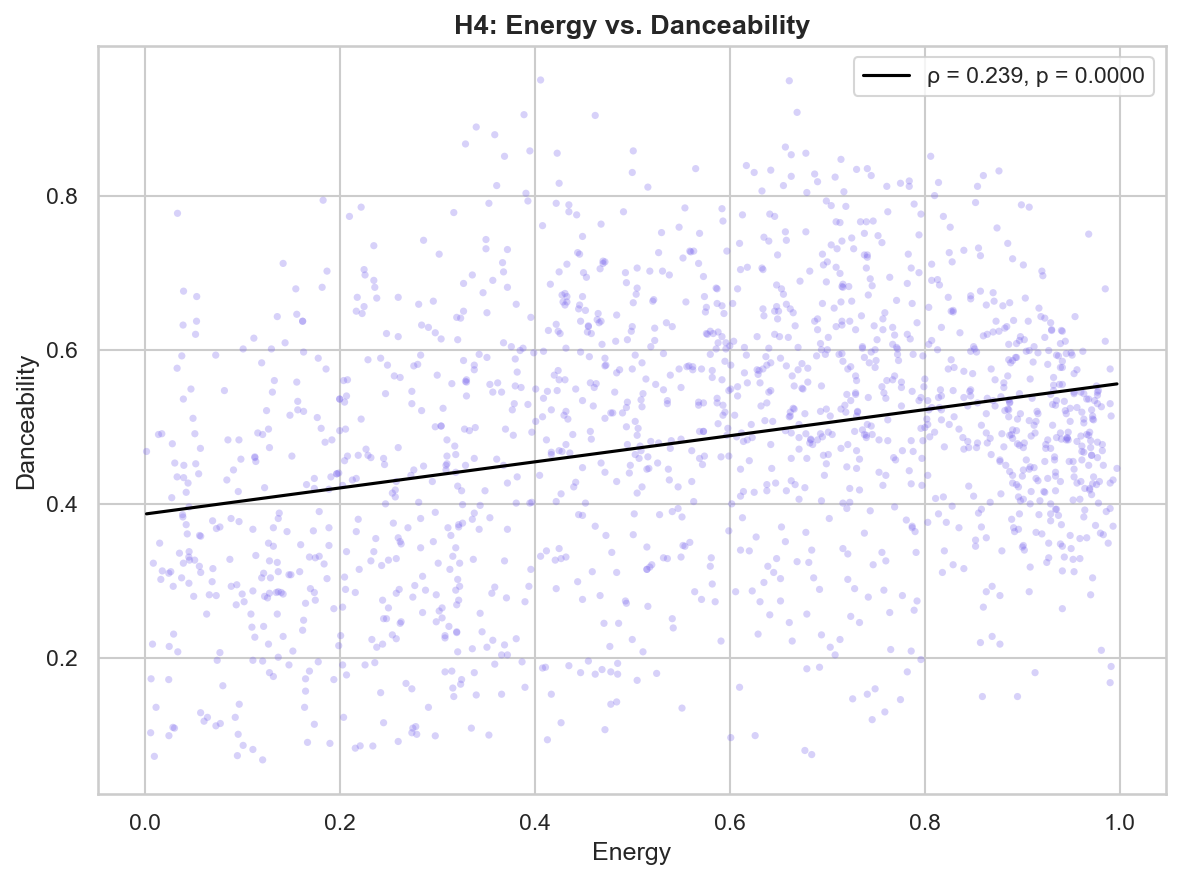

Saved: fig12_h4_energy_danceability.png


In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['energy'], df['danceability'],
           alpha=0.3, s=12, color='mediumslateblue', edgecolors='none')

# Regression line
m, b = np.polyfit(df['energy'], df['danceability'], 1)
x_line = np.linspace(df['energy'].min(), df['energy'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, label=f'ρ = {rho:.3f}, p = {p_one:.4f}')
ax.set_xlabel('Energy')
ax.set_ylabel('Danceability')
ax.set_title('H4: Energy vs. Danceability', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(IMAGES + 'fig12_h4_energy_danceability.png', bbox_inches='tight')
plt.show()
print('Saved: fig12_h4_energy_danceability.png')

## 4. Summary of Hypothesis Tests

In [21]:
results = pd.DataFrame([
    {'Hypothesis': 'H1: High-energy → more plays',
     'Test': 'Mann-Whitney U (one-tailed)',
     'p-value': round(p_val, 4),
     'Result': 'Reject H₀' if p_val < 0.05 else 'Fail to reject H₀'},
    {'Hypothesis': 'H2: Higher valence in summer vs winter',
     'Test': 'Mann-Whitney U (two-tailed)',
     'p-value': round(p_val2, 4),
     'Result': 'Reject H₀' if p_val2 < 0.05 else 'Fail to reject H₀'},
    {'Hypothesis': 'H3: Acoustic → lower tempo',
     'Test': 'Mann-Whitney U (one-tailed)',
     'p-value': round(p_val3, 4),
     'Result': 'Reject H₀' if p_val3 < 0.05 else 'Fail to reject H₀'},
    {'Hypothesis': 'H4: Energy & danceability positively correlated',
     'Test': 'Spearman ρ (one-tailed)',
     'p-value': round(p_one, 4),
     'Result': 'Reject H₀' if (p_one < 0.05 and rho > 0) else 'Fail to reject H₀'},
])
results

,Hypothesis,Test,p-value,Result
0,H1: High-energy → more plays,Mann-Whitney U (one-tailed),0.8707,Fail to reject H₀
1,H2: Higher valence in summer vs winter,Mann-Whitney U (two-tailed),0.8250,Fail to reject H₀
2,H3: Acoustic → lower tempo,Mann-Whitney U (one-tailed),0.0000,Reject H₀
3,H4: Energy & danceability positively correlated,Spearman ρ (one-tailed),0.0000,Reject H₀


## 5. Machine Learning Methods
### 5.1 ML Objective

In [ ]:

#The goal of this section is to predict whether a track is frequently played based on its Spotify audio features.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


# Create track-level dataset
track_ml = df.groupby(['trackName', 'artistName']).agg(
    play_count=('trackName', 'count'),
    danceability=('danceability', 'mean'),
    energy=('energy', 'mean'),
    loudness=('loudness', 'mean'),
    speechiness=('speechiness', 'mean'),
    acousticness=('acousticness', 'mean'),
    instrumentalness=('instrumentalness', 'mean'),
    liveness=('liveness', 'mean'),
    valence=('valence', 'mean'),
    tempo=('tempo', 'mean')
).reset_index()

# Binary target: frequently played or not
track_ml['frequently_played'] = (track_ml['play_count'] >= 2).astype(int)

track_ml.head()

features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo'
]

X = track_ml[features]
y = track_ml['frequently_played']

print(y.value_counts())
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=4),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5)
}

results_ml = []

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    results_ml.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results_ml)
results_df

best_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5)
best_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig(IMAGES + 'fig13_ml_feature_importance.png', bbox_inches='tight')
plt.show()


### 5.5 Interpretation

#The machine learning models were used to predict whether a track was frequently played based on its Spotify audio features. Logistic Regression was used as a simple baseline model, while Decision Tree and Random Forest were used to capture non-linear relationships.

#The model performances were compared using accuracy, precision, recall, and F1-score. Since the target variable is based on play frequency, the results show whether audio characteristics alone are sufficient to explain repeated listening behavior.

#The Random Forest feature importance plot shows which audio features contributed most to the prediction. This helps connect the machine learning results with the earlier EDA and hypothesis testing sections.
